# Creating Cohorts of Songs 

## Problem Scenario

The customer always looks forward to specialized treatment, whether shopping on an e-commerce website or watching Netflix. The customer desires content that aligns with their preferences. To maintain customer engagement, companies must consistently provide the most relevant information. 

Starting with Spotify, a Swedish audio streaming and media service provider, boasts over 456 million active monthly users, including more than 195 million paid subscribers as of September 2022. The company aims to create cohorts of different songs to enhance song recommendations. These cohorts will be based on various relevant features, ensuring that each group contains similar types of songs. 

### Problem Objective: 

As a data scientist, you should perform exploratory data analysis and cluster analysis to create cohorts of songs. The goal is to better understand the various factors that create a cohort of songs.

**Input dataset:** [song_data](https://drive.google.com/file/d/1IWlXWFi-0_toy_epV3-_95ciy12C-Sx6/view?usp=drive_link)

### Data Description: 

The dataset comprises information from Spotify's API regarding all albums by the Rolling Stones available on Spotify. It's crucial to highlight that each song possesses a unique ID. 

| Variable | Description |
|----------|-------------|
| name | It is the name of the song. |
| album | It is the name of the album. |
| release_date | It is the day, month, and year the album was released. |
| track number | It is the order in which the song appears on the album. |
| id | It is the Spotify ID for the song. |
| uri | It is the Spotify URI for the song. |
| acousticness | A confidence measure from 0.0 to 1.0 indicates whether the track is acoustic. 1.0 represents high confidence that the track is acoustic. |
| danceability | It describes how suitable a track is for dancing based on a combination of musical elements, including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is the least danceable, and 1.0 is the most danceable. |
| energy | It is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy. |
| instrumentalness | It predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal." The closer the instrumentalness value is to 1.0, the greater the likelihood that the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0. |
| liveness | It detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides a strong likelihood that the track is live. |
| loudness | The overall loudness of a track in decibels (dB) and loudness values are averaged across the entire track and are useful for comparing the relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typically range between -60 and 0 dB. |
| speechiness | It detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g., talk show, audiobook, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks. |
| tempo | The overall estimated tempo of a track is measured in beats per minute (BPM). In musical terminology, the tempo is the speed or pace of a given piece and derives directly from the average beat duration. |
| valence | A measure from 0.0 to 1.0 describes the musical positivity conveyed by a track. Tracks with high valence sound more positive (e.g., happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g., sad, depressed, angry). |
| popularity | The popularity of the song ranges from 0 to 100. |
| duration_ms | It is the duration of the track in milliseconds. |

### Steps to Perform: 

**Initial data inspection and data cleaning:** 

- Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. Check for any instances of erroneous entries and rectify them as needed 
- Refine the data for further processing based on your findings 

**Perform exploratory data analysis and feature engineering** 

- Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album 
- Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns 
- Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved 
- Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations

**Perform cluster analysis** 

- Identify the right number of clusters 
- Use appropriate clustering algorithms 
- Define each cluster based on the features


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, KernelPCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN, MeanShift, FeatureAgglomeration, OPTICS
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# Pull in our song data csv into a dataframe
song_df = pd.read_csv('../data/rolling_stones_spotify.csv')

# Display the first few rows of the dataframe
print(song_df.shape)
print(song_df.head())
print(song_df.info())
print(song_df.describe())
# print(song_df.isnull().sum()) # No missing/null data found

(1610, 18)
   Unnamed: 0                         name               album release_date  \
0           0   Concert Intro Music - Live  Licked Live In NYC   2022-06-10   
1           1   Street Fighting Man - Live  Licked Live In NYC   2022-06-10   
2           2           Start Me Up - Live  Licked Live In NYC   2022-06-10   
3           3  If You Can't Rock Me - Live  Licked Live In NYC   2022-06-10   
4           4          Donâ€™t Stop - Live  Licked Live In NYC   2022-06-10   

   track_number                      id                                   uri  \
0             1  2IEkywLJ4ykbhi1yRQvmsT  spotify:track:2IEkywLJ4ykbhi1yRQvmsT   
1             2  6GVgVJBKkGJoRfarYRvGTU  spotify:track:6GVgVJBKkGJoRfarYRvGTU   
2             3  1Lu761pZ0dBTGpzxaQoZNW  spotify:track:1Lu761pZ0dBTGpzxaQoZNW   
3             4  1agTQzOTUnGNggyckEqiDH  spotify:track:1agTQzOTUnGNggyckEqiDH   
4             5  7piGJR8YndQBQWVXv6KtQw  spotify:track:7piGJR8YndQBQWVXv6KtQw   

   acousticness  danceabili

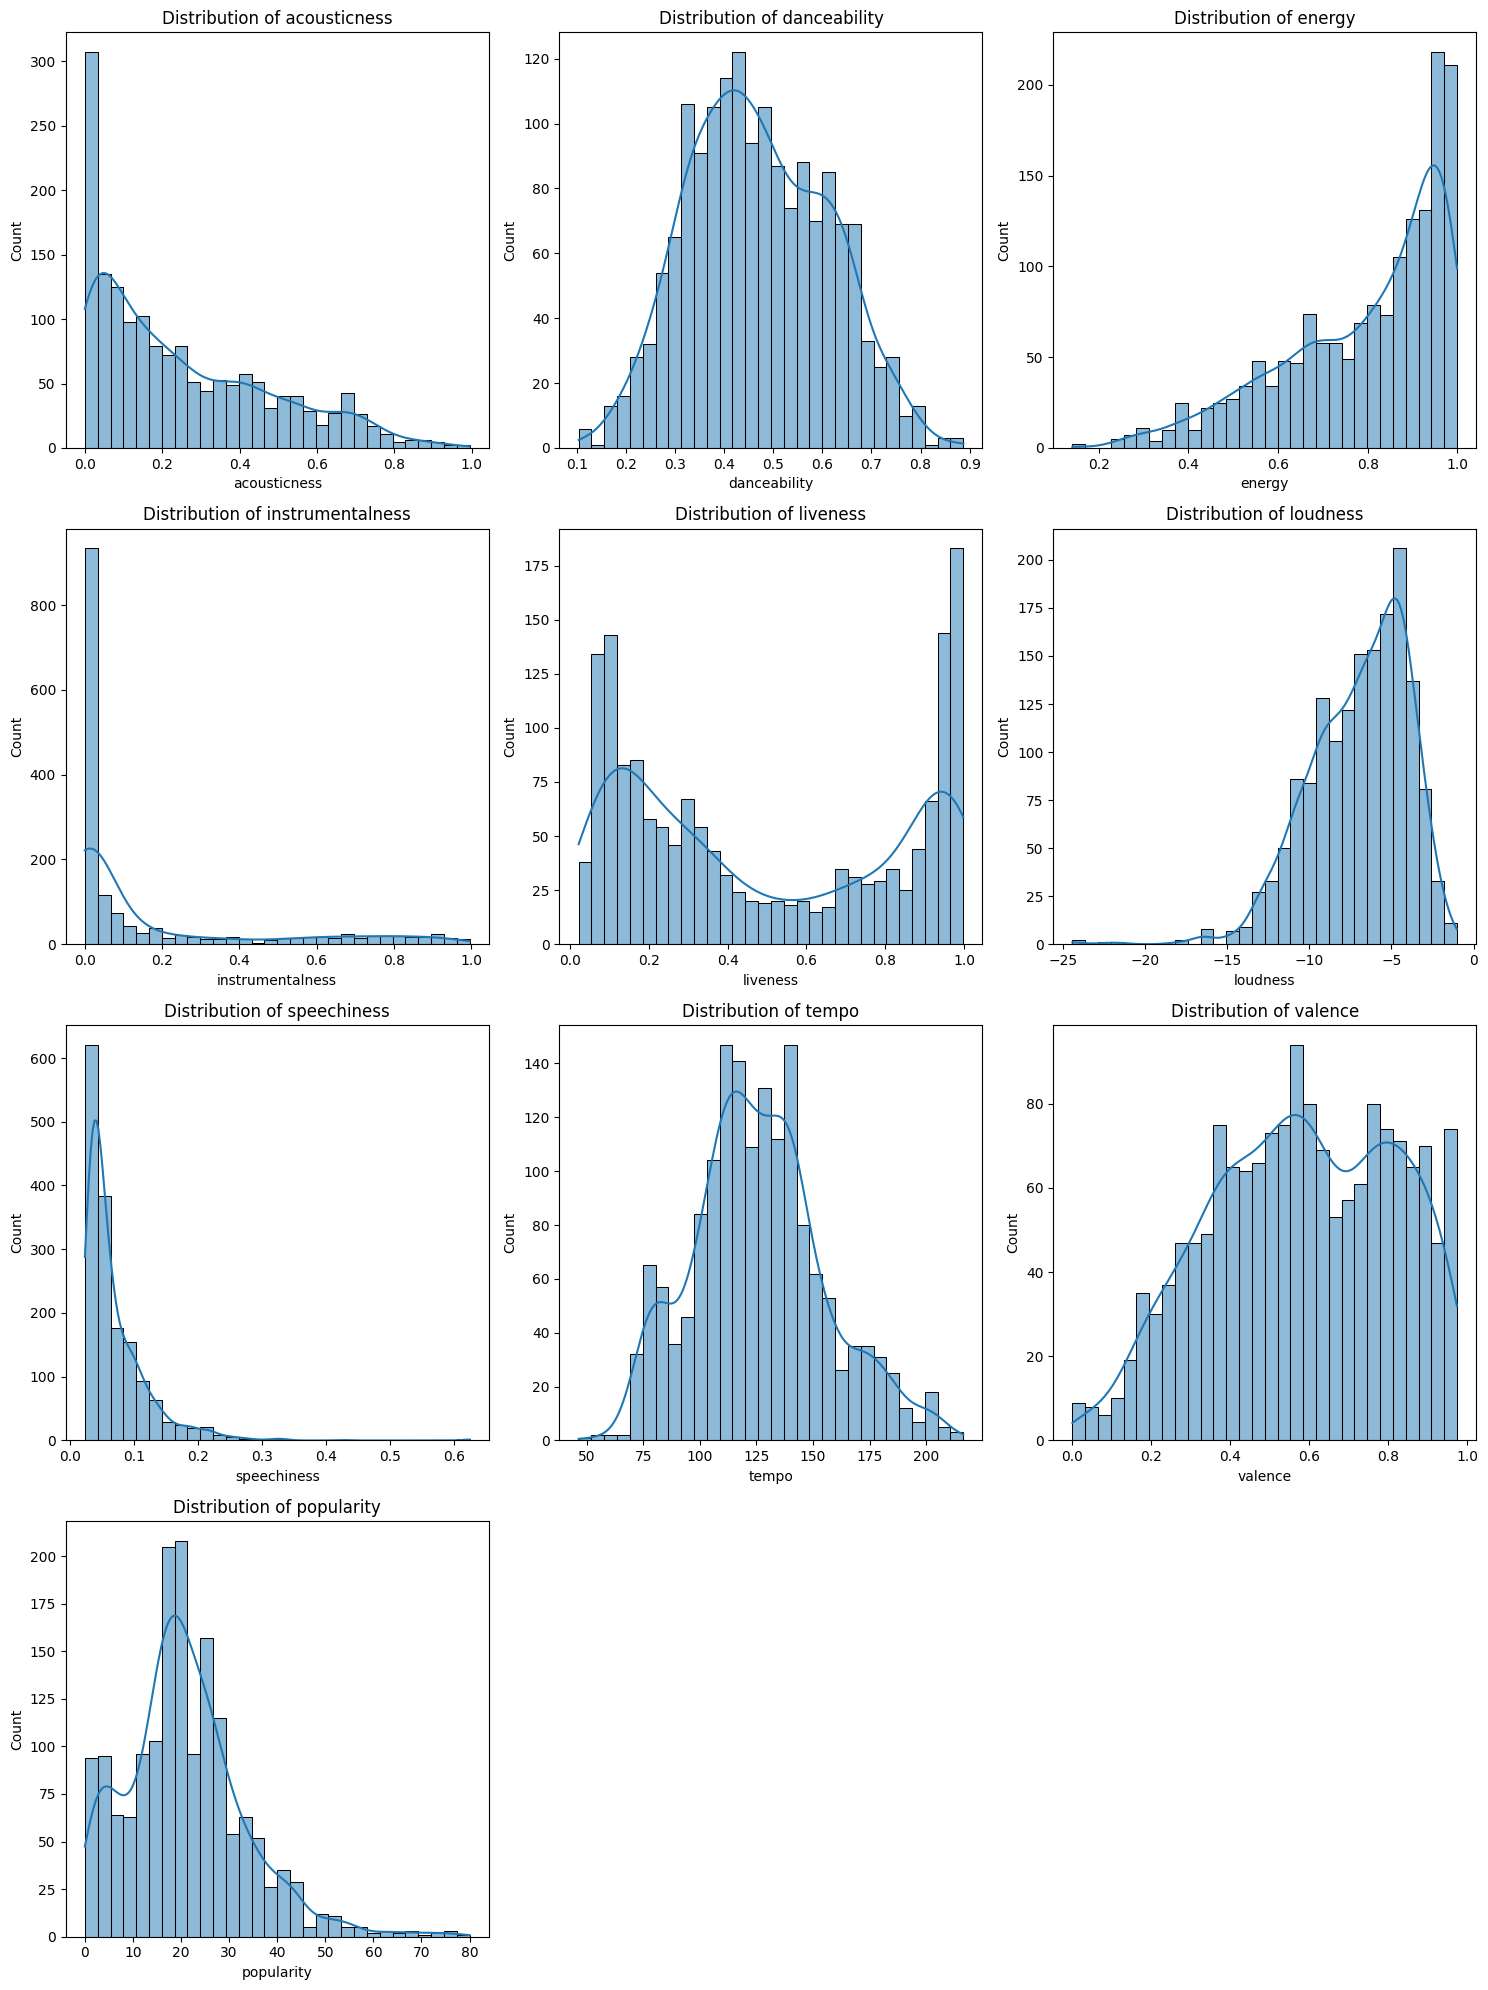

In [4]:
# Exploratory Data Analysis (EDA)
# Remove the 'Unnamed: 0' column
song_df = song_df.drop(columns=['Unnamed: 0'])
# remove columns that have useless information for cohort clustering
song_df_slimmed = song_df.drop(columns=['uri', 'track_number', 'name', 'album', 'duration_ms'])
song_df_num_dtypes = song_df_slimmed.select_dtypes(include=[np.number])

def plot_feature_distributions(df):
    features = df.select_dtypes(include=[np.number]).columns.tolist()
    num_features = len(features)
    cols = 3
    # Calculate number of rows needed
    rows = (num_features // cols) + (num_features % cols > 0)
    
    plt.figure(figsize=(15, 5 * rows))
    for i, feature in enumerate(features):
        plt.subplot(rows, cols, i + 1)
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'Distribution of {feature}')
    plt.tight_layout()
    plt.show()

plot_feature_distributions(song_df_slimmed)

### Popular Albums
- Here we can see the two most popular albums are Sitcky Fingers (Remastered) and Some Girls.
   - This was simple to do by grouping and averaging the popularity column by album name and sorting it in descending order

In [ ]:
# Plot out Albums in order according to the highest average of popular songs
album_popularity = song_df.groupby('album')['popularity'].mean().sort_values(ascending=False)
print(album_popularity)

In [ ]:
# Create a function that will 3d map all of our unique feature combinations on a surface plot using a target argument to pick out the target feature to use as our color mapping


def plot_3d_feature_surface(df, target_feature):
    features = df.select_dtypes(include=[np.number]).columns.tolist()
    features.remove(target_feature)
    combos = []
    
    cols = 4
    rows = 1
    fig = plt.figure(figsize=(20, 6))
    plot_index = 1
    for i, feature_x in enumerate(features):
        for j, feature_y in enumerate(features):
            for k, feature_z in enumerate(features):
                if set([feature_x, feature_y, feature_z]) not in combos and feature_x != feature_y and feature_x != feature_z and feature_y != feature_z:
                    combos.append(set([feature_x, feature_y, feature_z]))
                    ax = fig.add_subplot(rows, cols, plot_index, projection='3d')
                    # create a 3d surface plot and take the scipy gaussian kde of the 3 features as our surface plot and use the target feature to colormap over the surface
                    x = np.linspace(df[feature_x].min(), df[feature_x].max(), 50)
                    y = np.linspace(df[feature_y].min(), df[feature_y].max(), 50)
                    z = np.linspace(df[feature_z].min(), df[feature_z].max(), 50)
                    X, Y = np.meshgrid(x, y)
                    # Create a gaussian kde of the 2 features to create Z using our feature_z as the weighting
                    positions = np.vstack([X.ravel(), Y.ravel()])
                    values = np.vstack([df[feature_x], df[feature_y]])
                    kernel = stats.gaussian_kde(values, weights=df[feature_z])
                    Z = np.reshape(kernel(positions).T, X.shape)
                    # Scale Z back to its orignial feature max and min
                    Z = (Z - Z.min()) / (Z.max() - Z.min()) * (df[feature_z].max() - df[feature_z].min()) + df[feature_z].min()
                    # Normalize the target feature for color mapping
                    # Create color map dimensions based on target feature
                    # create gaussian of xy, yz, and xz by target feature and average them together for color mapping
                    xy = stats.gaussian_kde(values, weights=df[target_feature])
                    yz_values = np.vstack([df[feature_y], df[feature_z]])
                    yz = stats.gaussian_kde(yz_values, weights=df[target_feature])
                    xz_values = np.vstack([df[feature_x], df[feature_z]])
                    xz = stats.gaussian_kde(xz_values, weights=df[target_feature])
                    avg_kernel = (xy(positions) + yz(positions) + xz(positions)) / 3
                    cdim = np.reshape(avg_kernel.T, X.shape)
                    cnorm = plt.Normalize(cdim.min(), cdim.max())
                    # Create custom color map using our cdim
                    cma = plt.cm.ScalarMappable(norm=cnorm, cmap='viridis')
                    cma.set_array([])
                    fcolors = cma.to_rgba(cdim)
                    #remove any nan values from fcolors
                    fcolors = np.nan_to_num(fcolors)
                    
                    p = ax.plot_surface(X, Y, Z, cmap='viridis', facecolors=fcolors, rstride=1, cstride=1, linewidth=0.1, edgecolor='k')
                    ax.set_xlabel(feature_x)
                    ax.set_ylabel(feature_y)
                    ax.set_zlabel(feature_z, labelpad=-9)
                    ax.tick_params(axis='z', pad=-4)
                    # if we are the first plot, add a color bar to the left side
                    if plot_index == 1:
                        cax = ax.inset_axes([-0.05, 0, 0.05, 1], transform=ax.transAxes)
                        plt.colorbar(p, cax=cax, label=target_feature, location='left')
                    if plot_index == cols:
                        #create an inset axes to the right of our final subplot for the color bar
                        cax = ax.inset_axes([1.05, 0, 0.05, 1], transform=ax.transAxes)
                        
                        plt.colorbar(p, cax=cax, location='right')
                        plt.tight_layout()
                        plt.show()
                        fig = plt.figure(figsize=(20, 6))
                        plot_index = 1
                    else:
                        plot_index += 1
    # if there are leftover plots to show, plot them
    if plot_index != 1:
        plt.tight_layout()
        plt.show()

### Notes so far
- I could have done this with just two dimensions, but there would be way more graphs and not look as cool. So I went with 3D+1D surface plots
    - This was easier to make with the scatterplots but it was a lot harder to see where areas of popularity grouped up nicely
- One plot that kind of sticks out is the danceability vs energy vs valence plot. There is a very clear area of high popularity songs in the mid to high danceability, high energy, and high valence range.
    - This makes sense as songs that are more danceable, energetic, and positive are more likely to be popular. It was nice to see that reflected in these graphs, lending to their validity
- Another feature of these graphs, is that after doing some dimensionality reduction and clustering, we can retain the popularity column and plot it against the newly created clusters to see how popular each cluster is on average
    - This will help us define the clusters better and see which clusters are more popular than others

In [ ]:
# Exploratory Data Analysis (EDA)
# Takes about a minute to plot, uncomment to run
# plot_3d_feature_surface(song_df_slimmed, target_feature='popularity')

In [ ]:
# create a function that takes in a dataframe and gets the silhouette scores per number from multiple clustering techniques to determine the optimal number of clusters
def get_silhouette_scores(df):
    clustering_algorithms = {
        'DBSCAN': DBSCAN(eps=0.3, min_samples=10),
        'MeanShift': MeanShift(),
        'OPTICS': OPTICS(min_samples=10)
    }
    
    scores = {}
    for name, algorithm in clustering_algorithms.items():
        try:
            labels = algorithm.fit_predict(df)
            if len(set(labels)) > 1:  # silhouette score requires at least 2 clusters
                score = silhouette_score(df, labels)
                scores[name] = score
            else:
                scores[name] = 'Only one cluster found'
        except Exception as e:
            scores[name] = str(e)
    
    return scores

In [ ]:
def find_best_clustering(df_scaled, max_clusters=10):
    best_silhouette = -1
    best_n_clusters = 0
    for n_clusters in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(df_scaled)
        silhouette_avg = silhouette_score(df_scaled, cluster_labels)
        if silhouette_avg > best_silhouette:
            best_silhouette = silhouette_avg
            best_n_clusters = n_clusters
    print(f'Best silhouette score: {best_silhouette} with {best_n_clusters} clusters')

In [ ]:
# Dimensionality Reduction and Clustering will be done next
song_df_num_dtypes_scaled = StandardScaler().fit_transform(song_df_num_dtypes)
find_best_clustering(song_df_num_dtypes_scaled, max_clusters=10)

In [ ]:
# For a range of PCA components, plot the average popularity of each cluster to see if there is any correlation between clusters and popularity
def plot_cluster_popularity_correlation(df, scaled_data, target_feature, max_pca_components=10):
    for n_components in range(2, max_pca_components + 1):
        pca = PCA(n_components=n_components)
        pca_data = pca.fit_transform(scaled_data)
        
        kmeans = KMeans(n_clusters=n_components, random_state=42)
        cluster_labels = kmeans.fit_predict(pca_data)
        
        df_temp = df.copy()
        df_temp['Cluster'] = cluster_labels

        # Take the pca df and add the scaled popularity back in for cluster popularity calculation
        pca_df = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(n_components)])
        pca_df[target_feature] = df[target_feature].values
        pca_df['Cluster'] = cluster_labels
        # MinMax scale for no negative values
        mmscale = MinMaxScaler()
        pca_df_scaled = mmscale.fit_transform(pca_df)
        pca_df = pd.DataFrame(pca_df_scaled, columns=pca_df.columns)
        # plot with the 3d surface function
        plot_3d_feature_surface(pca_df, target_feature=target_feature)
        
        cluster_popularity = pca_df.groupby('Cluster')[target_feature].mean()
        # print the weights of the original features in the PCA components and use the original features' labels on the weights
        print(f'PCA Components: {n_components}')
        print('PCA Component Weights:')
        for i, component in enumerate(pca.components_):
            weights = {df_temp.select_dtypes(include=[np.number]).columns[j]: component[j] for j in range(len(component))}
            sorted_weights = dict(sorted(weights.items(), key=lambda item: abs(item[1]), reverse=True))
            for j, weight in enumerate(sorted_weights):
                if j < 4:  # print top 4 weights per component
                    print(f'Component {i+1}: {weight} - {sorted_weights[weight]}')
        # Print silhouette score for this clustering
        silhouette_avg = silhouette_score(pca_data, cluster_labels)
        print(f'Silhouette Score for {n_components} components: {silhouette_avg}')
        plt.figure(figsize=(8, 5))
        sns.barplot(x=cluster_popularity.index, y=cluster_popularity.values)
        plt.title(f'Average {target_feature} by Cluster (PCA Components: {n_components})')
        plt.xlabel('Cluster')
        plt.ylabel(f'Average {target_feature}')
        plt.show()
        
plot_cluster_popularity_correlation(song_df, song_df_num_dtypes_scaled, target_feature='popularity', max_pca_components=10)

### Final Notes
- Using solely a silhouette score it seemed that 2 clusters was the best choice, but after plotting them out and looking at the average popularity of the clusters and trying to find correlations, I thought that 4 or 5 clusters seemed to work better
    - There were multiple peaks and overlaps in the original 3d surface plots I was making that seemed to indicate a lot of groupings of correlated to both high and low popularity.
    - Things like higher danceability, higher energy, and high valence seemed to be the most important features in determining higher popularity
    - On the other end, features like high acousticness, low valence, and high speechiness seemed to correlate more with lower popularity songs
- These are reflected in the PCA breakdowns while showing how a there were feature that contributed to the overall cluster in both positive and negative ways